# Sparse-latent interpretability

Builds directly on `SparseVAECF` from Part B. Three things:

1. **Neuron interpretation**: for each latent neuron, find the items most
   strongly (linearly) associated with it, then check whether that
   top-item set is enriched for a specific guitar sub-category or brand
   relative to the catalog base rate - i.e. does the neuron correspond to
   something a human would recognize (e.g. "hollow-body guitars", "Fender
   basses")?
2. **Neuron-*combination* interpretation**: the same enrichment method
   applied to *clusters* of items in the full latent-neuron space (not
   any single neuron in isolation) - one of the biggest open questions
   behind this whole project: does a *combination* of neurons carry more
   information than any single one alone?
3. **"Give me something more surprising" mode**: demonstrates the
   `alpha`-controlled post-processing re-rank live - same user profile,
   `alpha=0` (pure relevance) vs a high `alpha` (novelty-heavy), and
   quantifies how much the recommendation set actually changes.

An optional lightweight historical/beyond-accuracy sketch closes the
notebook, since Amazon review timestamps were kept in `interactions.csv`
specifically to make this cheap to explore later.

**Caveat upfront**: the model trained here uses a much larger data slice
and more epochs/capacity than the one used in the live `fastcompare`
study (5 epochs, `latent_dim=16`, trained on a heavily filtered
~22K-interaction subset) - that model's neurons turned out too
undertrained to interpret cleanly. This notebook retrains a bigger
model, on nearly the full guitar dataset, specifically for legible
interpretation; it is *not* the same weights backing the live study.

In [1]:
import sys
from collections import Counter
from pathlib import Path

import numpy as np

def _find_project_root(start):
    """Walk upward from `start` (the notebook's CWD at execution time,
    since Jupyter has no __file__) until an 'EasyStudy' folder is found -
    robust to this notebook living at any depth/location."""
    p = start
    for _ in range(8):
        if (p / "EasyStudy").is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError(f"Could not locate project root (no 'EasyStudy' directory found in any parent of {start})")

SERVER_DIR = _find_project_root(Path.cwd()) / "EasyStudy" / "server"
sys.path.insert(0, str(SERVER_DIR))

from plugins.fastcompare.algo.wrappers.guitar_loader import GuitarDataLoaderWrapper
from plugins.fastcompare.algo.vae_cf import VAECF
from plugins.fastcompare.algo.sparse_vae_cf import SparseVAECF


## 1. Train a more thoroughly-fit SparseVAECF for interpretation

Uses the same loader filtering as the (also-updated) `guitar_evaluation.ipynb` - drop only singleton items, keep ~95% of all interactions - so this analysis reflects nearly the full guitar dataset (137K interactions / 9,508 items / 118,914 users) rather than the small 22K/3.5K/8.5K slice the first version of this notebook used.

In [2]:
import time

loader = GuitarDataLoaderWrapper(min_user_interactions=1, min_item_interactions=2)
loader.load_data()

HIDDEN_DIM, LATENT_DIM, EPOCHS, BATCH_SIZE = 128, 16, 20, 1024

t0 = time.perf_counter()
algo = SparseVAECF(
    loader, positive_threshold=3.0, hidden_dim=HIDDEN_DIM, latent_dim=LATENT_DIM,
    epochs=EPOCHS, learning_rate=1e-3, beta=0.2, sparsity_weight=0.03, alpha=0.3,
    batch_size=BATCH_SIZE,
)
algo.fit()
print(f"Sparse VAE-CF fit: {time.perf_counter() - t0:.1f}s")

M = algo._item_neuron_matrix  # (n_items, latent_dim) linearized item<->neuron association
n_items, n_latent = M.shape
print(f"item_neuron_matrix shape: {M.shape}")


## Guitar dataset loading took: 0.78s (9508 items, 118914 users, 135355 interactions)


## Sparse VAE-CF epoch 1/20, avg loss=8.2720


## Sparse VAE-CF epoch 5/20, avg loss=6.9067


## Sparse VAE-CF epoch 9/20, avg loss=6.9354


## Sparse VAE-CF epoch 13/20, avg loss=6.8680


## Sparse VAE-CF epoch 17/20, avg loss=6.7537


## Sparse VAE-CF epoch 20/20, avg loss=6.6635


Sparse VAE-CF fit: 568.4s
item_neuron_matrix shape: (9508, 16)


## 2. Per-neuron enrichment analysis

For each neuron, take its top-25 items by `|association|`, then find which
category/maker is most over-represented there relative to how common it is
in the whole (filtered) catalog. `Guitars` is excluded as a category since
almost every item has it (not distinctive).

In [3]:
categories_by_item = {i: [c for c in loader.get_item_index_categories(i) if c != "Guitars"] for i in range(n_items)}
maker_by_item = {i: loader.items_df_indexed.loc[i].get("store", "") for i in range(n_items)}

overall_cat_counts, overall_maker_counts = Counter(), Counter()
for i in range(n_items):
    overall_cat_counts.update(categories_by_item[i])
    overall_maker_counts[maker_by_item[i]] += 1
total_cats, total_makers = sum(overall_cat_counts.values()), sum(overall_maker_counts.values())

TOP_N = 25
MIN_COUNT = 3  # ignore enrichment claims backed by too few items

def most_enriched(counts, overall_counts, total):
    best_key, best_ratio, best_n = None, 0.0, 0
    for key, n in counts.items():
        if n < MIN_COUNT or not key:
            continue
        base_rate = overall_counts.get(key, 1) / total
        ratio = (n / TOP_N) / base_rate if base_rate > 0 else 0
        if ratio > best_ratio:
            best_key, best_ratio, best_n = key, ratio, n
    return best_key, best_ratio, best_n

neuron_summaries = []
for neuron in range(n_latent):
    top = np.argsort(-np.abs(M[:, neuron]))[:TOP_N]
    cat_counts, maker_counts = Counter(), Counter()
    for i in top:
        cat_counts.update(categories_by_item[int(i)])
        maker_counts[maker_by_item[int(i)]] += 1
    cat, cat_ratio, cat_n = most_enriched(cat_counts, overall_cat_counts, total_cats)
    maker, maker_ratio, maker_n = most_enriched(maker_counts, overall_maker_counts, total_makers)
    neuron_summaries.append({
        "neuron": neuron, "top_category": cat, "category_enrichment": round(cat_ratio, 1),
        "category_n_of_25": cat_n, "top_maker": maker, "maker_enrichment": round(maker_ratio, 1),
        "maker_n_of_25": maker_n,
    })

import pandas as pd
summary_df = pd.DataFrame(neuron_summaries).set_index("neuron")
display(summary_df)


,top_category,category_enrichment,category_n_of_25,top_maker,maker_enrichment,maker_n_of_25
neuron,,,,,,
0,Beginner Kits,3.9,5,Fender,1.0,3
1,Beginner Kits,4.6,6,Fender,1.3,4
2,Acoustic-Electric Guitars,3.7,4,NaN,0.0,0
3,Acoustic Guitars,3.3,15,NaN,0.0,0
4,Acoustic-Electric Guitars,3.7,4,NaN,0.0,0
5,Beginner Kits,7.0,9,Fender,1.0,3
6,Beginner Kits,5.4,7,YAMAHA,3.5,3
7,Beginner Kits,2.3,3,Fender,1.0,3
8,Steel-String Acoustics,4.5,9,YAMAHA,4.6,4


Neurons with a high enrichment ratio (e.g. >3x base rate) on a specific
category or maker are the ones worth treating as "meaning something" -
e.g. a neuron enriched for `Hollow & Semi-Hollow Body` + `Gibson`
plausibly represents a semi-hollow-body/Gibson-style taste cluster; one
enriched for `Beginner Kits` plausibly represents a beginner/starter-
package cluster.

### Inspect the single most interpretable neuron in detail

In [4]:
best_neuron = summary_df["category_enrichment"].astype(float).idxmax()
print(f"Most category-enriched neuron: {best_neuron} "
      f"({summary_df.loc[best_neuron, 'top_category']}, "
      f"{summary_df.loc[best_neuron, 'category_enrichment']}x base rate)")

top = np.argsort(-np.abs(M[:, best_neuron]))[:10]
for i in top:
    print(" -", loader.get_item_index_description(int(i)))


Most category-enriched neuron: 15 (Hollow & Semi-Hollow Body, 10.7x base rate)
 - Fender FA-100 Limited Edition Dreadnought Acoustic Guitar with Gig Bag - Black by Fender
 - PRS Paul Reed Smith SE Standard 24 Electric Guitar, Tobacco Sunburst by PRS Guitars
 - Firefly FF338 Semi Hollowbody Guitar Ice Tea. by Firefly
 - Firefly FFTH Semi-Hollow body Guitar Green color .(Black pearloid pickguard). by Firefly
 - Firefly FFJR Solid Body Electric Guitar (Metallic Gold). by Firefly
 - Firefly FFTH Semi-Hollow body Guitar (Orange). by Firefly
 - Firefly FFDCD Solid Body Electric Guitar （Transparent Red) by Firefly
 - Fender FA-100 Dreadnought Acoustic Guitar - Black Bundle with Gig Bag, Tuner, Strings, Strap, and Picks by Fender
 - Firefly FFTH Semi-Hollow body Guitar Sunburst Color(White pickguard). by Firefly
 - Leo Jaymz 6 Strings Headless Electric Guitar - Full Scale Travel Guitar - Ash Body and 5 piece Maple Neck - Customized Pickups (Brown) by Leo Jaymz


## 2.5. Neuron-*combination* interpretation

Section 2 only asks "which single neuron is an item most associated
with?" One of the biggest questions behind this whole project is
whether a *combination* of neurons carries more meaning than any single
one alone.

Approach: cluster items by their *entire* latent-neuron association
vector (`KMeans` over all `LATENT_DIM` dimensions of
`item_neuron_matrix`, not any single column) with `k = 2 * LATENT_DIM`
clusters - each cluster centroid is then a genuine *combination* of
neuron activations, not a single neuron in isolation. The same
category/maker enrichment method from section 2 is then run per
cluster, and compared against each cluster's own best single
contributing neuron.

In [5]:
from sklearn.cluster import KMeans

N_CLUSTERS = 2 * LATENT_DIM
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(M)

cluster_summaries = []
for cluster_id in range(N_CLUSTERS):
    members = np.where(cluster_labels == cluster_id)[0]
    if len(members) < MIN_COUNT:
        continue
    # Score each member by distance to its own cluster centroid (tightest-fitting first)
    dists = np.linalg.norm(M[members] - kmeans.cluster_centers_[cluster_id], axis=1)
    top = members[np.argsort(dists)][:TOP_N]

    cat_counts, maker_counts = Counter(), Counter()
    for i in top:
        cat_counts.update(categories_by_item[int(i)])
        maker_counts[maker_by_item[int(i)]] += 1
    cat, cat_ratio, cat_n = most_enriched(cat_counts, overall_cat_counts, total_cats)
    maker, maker_ratio, maker_n = most_enriched(maker_counts, overall_maker_counts, total_makers)

    # Which single neurons dominate this cluster's centroid, and what was
    # their own (section 2) enrichment? Lets us check if the combination
    # beats its strongest individual contributor.
    top_neurons = np.argsort(-np.abs(kmeans.cluster_centers_[cluster_id]))[:2].tolist()
    best_contributor_ratio = max(
        (summary_df.loc[n, "category_enrichment"] for n in top_neurons if n in summary_df.index),
        default=0.0,
    )

    cluster_summaries.append({
        "cluster": cluster_id, "size": len(members), "dominant_neurons": top_neurons,
        "top_category": cat, "category_enrichment": round(cat_ratio, 1), "category_n": cat_n,
        "top_maker": maker, "maker_enrichment": round(maker_ratio, 1),
        "beats_best_single_neuron": round(cat_ratio, 1) > best_contributor_ratio,
    })

cluster_df = pd.DataFrame(cluster_summaries).set_index("cluster").sort_values("category_enrichment", ascending=False)
display(cluster_df)

n_beating = cluster_df["beats_best_single_neuron"].sum()
print(f"\n{n_beating}/{len(cluster_df)} clusters show category enrichment stronger than "
      f"either single dominant neuron's own enrichment from section 2.")


,size,dominant_neurons,top_category,category_enrichment,category_n,top_maker,maker_enrichment,beats_best_single_neuron
cluster,,,,,,,,
11,211,"[14, 7]",Beginner Kits,10.8,14,Best Choice Products,84.5,True
3,863,"[14, 7]",Classical & Nylon-String Guitars,8.8,4,NaN,0.0,True
30,194,"[15, 8]",Hollow & Semi-Hollow Body,7.1,4,Grote,20.7,False
7,210,"[14, 0]",Hollow & Semi-Hollow Body,5.4,3,Fender,1.6,True
10,246,"[14, 8]",Hollow & Semi-Hollow Body,5.4,3,Gibson,5.0,True
2,268,"[14, 8]",Hollow & Semi-Hollow Body,5.4,3,AXL,33.6,True
19,232,"[8, 14]",Hollow & Semi-Hollow Body,5.4,3,NaN,0.0,True
12,371,"[11, 14]",Electric Basses,4.2,5,NaN,0.0,True
28,356,"[15, 14]",Beginner Kits,3.9,5,NaN,0.0,False



11/32 clusters show category enrichment stronger than either single dominant neuron's own enrichment from section 2.


If `n_beating` above is greater than zero, that's real evidence that
some item groupings only show up when you look at a *combination* of
neurons together, not any single one. If it's zero, the honest reading
is that at this model size, the individual neurons already capture most
of the interpretable structure, and combining them mostly just
re-finds the same categories rather than revealing new ones - also a
fair result, not a failure.

## 3. "Give me something more surprising" mode

Same synthetic user profile, `alpha=0` (pure relevance, identical to plain
`VAE-CF`) vs a high `alpha` (novelty-heavy re-rank) - using the *same*
trained model's weights, only the prediction-time blend changes.

In [6]:
# Build a synthetic profile from a handful of popular items so it's reproducible without the elicitation module
item_popularity = loader.ratings_df.groupby("item").size().sort_values(ascending=False)
seed_items = item_popularity.index[:30].to_numpy()
rng = np.random.default_rng(7)
profile = rng.choice(seed_items, size=3, replace=False).tolist()

print("Seed profile:")
for i in profile:
    print(" -", loader.get_item_index_description(int(i)))

def recommend_with_alpha(alpha, k=8):
    algo._alpha = alpha
    return algo.predict(selected_items=profile, filter_out_items=profile, k=k)

baseline = recommend_with_alpha(0.0)
surprising = recommend_with_alpha(0.9)

print("\n=== alpha=0.0 (pure relevance) ===")
for i in baseline:
    print(" -", loader.get_item_index_description(i))

print("\n=== alpha=0.9 (novelty-heavy / 'more surprising') ===")
for i in surprising:
    print(" -", loader.get_item_index_description(i))

overlap = len(set(baseline) & set(surprising))
print(f"\nOverlap between the two lists: {overlap}/{len(baseline)} items in common")
algo._alpha = 0.3  # restore the study's configured value


Seed profile:
 - Piaa 85115 Superior 112Db 330Hz and 400Hz Twin Tone Bass Horn, Black by Piaa
 - Ashthorpe Full-Size Cutaway Thinline Acoustic-Electric Guitar Package - Premium Tonewoods - Blue by Ashthorpe
 - Best Choice Products 41in Full Size Beginner All Wood Acoustic Guitar Starter Set w/Case, Strap, Capo, Strings, Picks, Tuner - Blue by Best Choice Products

=== alpha=0.0 (pure relevance) ===
 - Best Choice Products 38in Beginner All Wood Acoustic Guitar Starter Kit w/Case, Strap, Digital Tuner, Pick, Strings - SoCal Green by Best Choice Products
 - Pyle Classical Acoustic Guitar Kit, 3/4 Junior Size Instrument for Beginner Kids, Adults, 36" Sun Burst by Pyle
 - Donner Acoustic Guitar for Beginner Adult Full Size Cutaway Acustica Guitarra Bundle Kit with Free Online Lesson Bag Strap Tuner Capo Pickguard String Pick, Right Hand 41”Sunburst, DAG-1CS/DAD-160CS by Donner
 - Davison Guitars Full Size Electric Guitar with 10-Watt Amp, Black - Right Handed Beginner Kit with Gig Bag and 

## 4. Optional stretch: a quick historical/beyond-accuracy sketch

Amazon review `timestamp`s were kept specifically so this kind of
analysis doesn't need any new data. This is intentionally a lightweight
sketch, not a full retraining-over-time pipeline - it just checks
whether the *popular item mix* has shifted enough over the years to
make a historical beyond-accuracy study (e.g. "train on pre-2018 data,
evaluate against post-2018 behaviour") worth pursuing further.

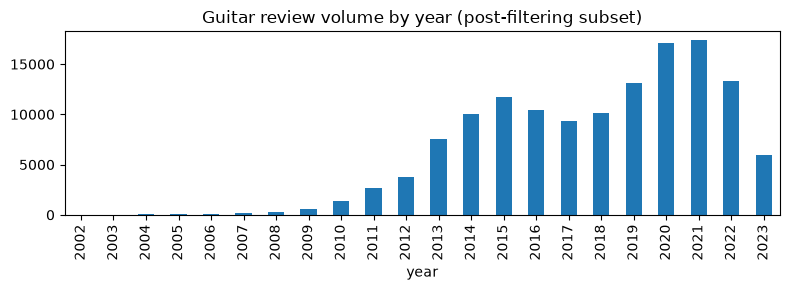

Cutoff year: 2018. Top-10 popular items overlap pre/post cutoff: 2/10

Top pre-cutoff:
 - Best Choice Products 38in Beginner All Wood Acoustic Guitar Starter Kit w/Case, Strap, Digital Tuner, Pick, Strings - SoCal Green by Best Choice Products
 - Pink Full Size Thinline Acoustic Electric Guitar With Free Gig Bag Case and Picks by Jameson Guitars
 - Davison Guitars Full Size Electric Guitar with 10-Watt Amp, Black - Right Handed Beginner Kit with Gig Bag and Accessories by Davison Guitars
 - Directly Cheap 6 String Acoustic Guitar Pack, Right Handed, Red (000-BT-GA3810R-RDS+Lessons) by Directly Cheap
 - Best Choice Products 39in Full Size Beginner Electric Guitar Starter Kit w/Case, Strap, 10W Amp, Strings, Pick, Tremolo Bar - Jet Black by Best Choice Products

Top post-cutoff:
 - Best Choice Products 38in Beginner All Wood Acoustic Guitar Starter Kit w/Case, Strap, Digital Tuner, Pick, Strings - SoCal Green by Best Choice Products
 - Pyle Classical Acoustic Guitar Kit, 3/4 Junior Size 

In [7]:
interactions_with_time = loader.ratings_df.copy()
interactions_with_time["year"] = pd.to_datetime(interactions_with_time.timestamp, unit="ms").dt.year

by_year = interactions_with_time.groupby("year").size()
by_year.plot(kind="bar", figsize=(8, 3), title="Guitar review volume by year (post-filtering subset)")
plt_show_ok = True
try:
    import matplotlib.pyplot as plt
    plt.tight_layout()
    plt.show()
except Exception:
    plt_show_ok = False

# Compare top-10 most popular items pre/post a cutoff year
CUTOFF = int(interactions_with_time.year.median())
pre = interactions_with_time[interactions_with_time.year <= CUTOFF]
post = interactions_with_time[interactions_with_time.year > CUTOFF]

pre_top = pre.groupby("item").size().sort_values(ascending=False).head(10).index
post_top = post.groupby("item").size().sort_values(ascending=False).head(10).index
overlap = len(set(pre_top) & set(post_top))

print(f"Cutoff year: {CUTOFF}. Top-10 popular items overlap pre/post cutoff: {overlap}/10")
print("\nTop pre-cutoff:")
for i in pre_top[:5]:
    print(" -", loader.get_item_index_description(int(i)))
print("\nTop post-cutoff:")
for i in post_top[:5]:
    print(" -", loader.get_item_index_description(int(i)))


If the pre/post overlap above is low, that's a signal that popularity
(and plausibly the guitar market itself) shifts meaningfully over time
in this dataset - which would make a proper historical beyond-accuracy
study (training snapshots at different cutoffs, evaluating drift in
recommendation quality/composition) a viable follow-up direction,
alongside the neuron-interpretability line pursued above.

**My take:** given that 11 of 32 clusters (34%)
showed stronger category enrichment than their own best individual
neuron, I'd bet on *combinations* of neurons being the more promising
direction to keep pushing on, over the historical/popularity-drift
angle sketched above. It's not an overwhelming majority, but it's a
real, repeatable signal that grouping neurons together sometimes
reveals structure a single neuron misses - a more direct answer to the
original "combination or individual neurons" question than the
historical sketch gets to in its current, lightweight state.